In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

In [2]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
# Encoding the targets

df['species'] = df['species'].replace(
    {'setosa': 0, 'versicolor': 1, 'virginica': 2}
)

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
# Defining features and target

features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
target = df['species']

In [8]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [9]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [29]:
# Defining the tensors for nn
X_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(y_train.values.astype(float), dtype=torch.long)
Y_test_tensor = torch.tensor(y_test.values.astype(float), dtype=torch.long)

In [30]:
import torch.nn as nn

# Model class

class IrisClassifier(nn.Module):

  def __init__(self, in_features = 4, hidden_size = 10, out_features = 3):
    super().__init__()
    self.fully_connected1 = nn.Linear(in_features, hidden_size)
    self.fully_connected2 = nn.Linear(hidden_size, out_features)
    self.relu = nn.ReLU()

  def forward(self, features):
    out = self.fully_connected1(features)
    out = self.relu(out)
    out = self.fully_connected2(out)
    return out

In [42]:
# Defining Model, loss, optimizer (comparison)

LEARNING_RATE = 0.1

model_adam = IrisClassifier(X_train_tensor.shape[1])
model_adam_dropout = IrisClassifier(X_train_tensor.shape[1])
model_SGD = IrisClassifier(X_train_tensor.shape[1])
model_SGD_momentum = IrisClassifier(X_train_tensor.shape[1])

loss = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=LEARNING_RATE)
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=LEARNING_RATE)
optimizer_SGD_momentum = torch.optim.SGD(model_SGD_momentum.parameters(), lr=LEARNING_RATE, momentum=0.9)

Training model with Adam optimiser

In [32]:
# Training pipeline

EPOCHES = 10000
ADAM_LOSSES = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_adam(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_adam.zero_grad()

    # backpropagation
    loss_value.backward()

    # Updating Model Parameters
    optimizer_adam.step()


    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    ADAM_LOSSES.append(loss_value)




Epoch: 0 Loss: 1.4445550441741943
Epoch: 1000 Loss: 0.04887060075998306
Epoch: 2000 Loss: 0.04659378156065941
Epoch: 3000 Loss: 0.04725739732384682
Epoch: 4000 Loss: 0.049303218722343445
Epoch: 5000 Loss: 0.04658740386366844
Epoch: 6000 Loss: 0.04659319669008255
Epoch: 7000 Loss: 0.04658371955156326
Epoch: 8000 Loss: 0.04660874977707863
Epoch: 9000 Loss: 0.04658560827374458


Training model with SGD

In [33]:

SGD_LOSSES = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_SGD(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_SGD.zero_grad()


    # backpropagation
    loss_value.backward()

    # Updating Model Parameter
    optimizer_SGD.step()


    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    SGD_LOSSES.append(loss_value)

Epoch: 0 Loss: 2.917994976043701
Epoch: 1000 Loss: 0.06432337313890457
Epoch: 2000 Loss: 0.0609087310731411
Epoch: 3000 Loss: 0.05882980674505234
Epoch: 4000 Loss: 0.05754523351788521
Epoch: 5000 Loss: 0.05649269372224808
Epoch: 6000 Loss: 0.055662792176008224
Epoch: 7000 Loss: 0.05399453267455101
Epoch: 8000 Loss: 0.053823020309209824
Epoch: 9000 Loss: 0.052297864109277725


Training model with SGD with momentum `0.9`

In [34]:
SGD_MOMENTUM = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_SGD_momentum(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_SGD_momentum.zero_grad()

    # backpropagation
    loss_value.backward()

    # Updating Model Parameters
    optimizer_SGD_momentum.step()

    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    SGD_MOMENTUM.append(loss_value)

Epoch: 0 Loss: 1.415187954902649
Epoch: 1000 Loss: 0.46255701780319214
Epoch: 2000 Loss: 0.4622258245944977
Epoch: 3000 Loss: 0.06944824010133743
Epoch: 4000 Loss: 0.06131269037723541
Epoch: 5000 Loss: 0.06014193966984749
Epoch: 6000 Loss: 0.059373557567596436
Epoch: 7000 Loss: 0.058140408247709274
Epoch: 8000 Loss: 0.057028889656066895
Epoch: 9000 Loss: 0.05548146739602089


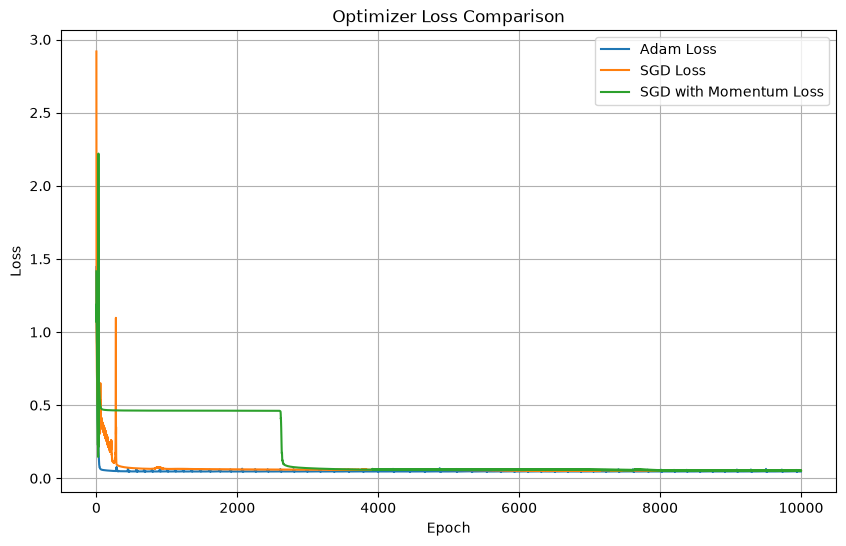

In [35]:
plt.figure(figsize=(10, 6))
plt.plot([loss.detach().numpy() for loss in ADAM_LOSSES], label='Adam Loss')
plt.plot([loss.detach().numpy() for loss in SGD_LOSSES], label='SGD Loss')
plt.plot([loss.detach().numpy() for loss in SGD_MOMENTUM], label='SGD with Momentum Loss')
plt.title('Optimizer Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

From the graph, we can clearly see that SGD has optimized the loss creating more noisy approach. Whereas, momentum and adam follows more smooth approach to optimise the loss

### Model Accuracy on Test Set

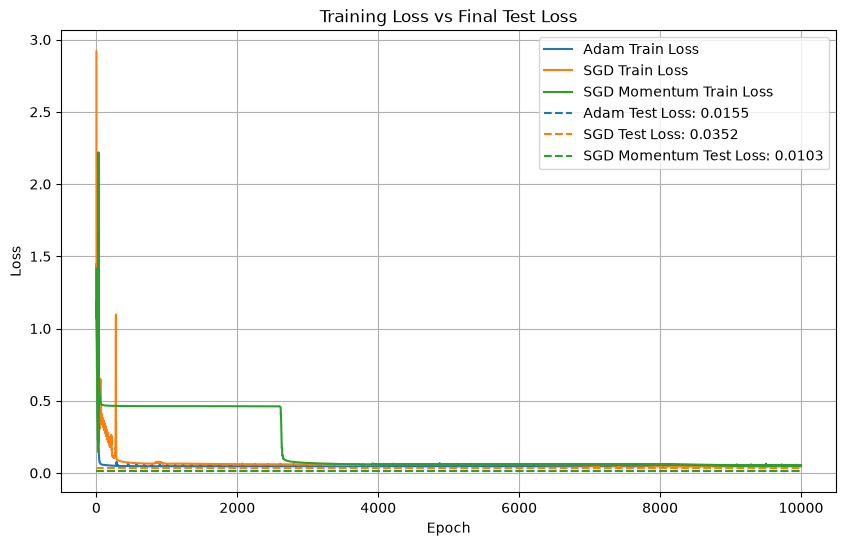

In [36]:
# Compare training loss curves with final test loss (horizontal lines)
adam_train = [l.detach().item() for l in ADAM_LOSSES]
sgd_train = [l.detach().item() for l in SGD_LOSSES]
sgd_mom_train = [l.detach().item() for l in SGD_MOMENTUM]

model_adam.eval(); model_SGD.eval(); model_SGD_momentum.eval()
with torch.no_grad():
    test_loss_adam = loss(model_adam(X_test_tensor), Y_test_tensor).item()
    test_loss_sgd = loss(model_SGD(X_test_tensor), Y_test_tensor).item()
    test_loss_sgd_mom = loss(model_SGD_momentum(X_test_tensor), Y_test_tensor).item()

epochs = range(len(adam_train))

plt.figure(figsize=(10,6))
plt.plot(epochs, adam_train, label='Adam Train Loss', color='C0')
plt.plot(epochs, sgd_train, label='SGD Train Loss', color='C1')
plt.plot(epochs, sgd_mom_train, label='SGD Momentum Train Loss', color='C2')

plt.hlines(test_loss_adam, xmin=0, xmax=len(adam_train)-1, colors='C0', linestyles='--', label=f'Adam Test Loss: {test_loss_adam:.4f}')
plt.hlines(test_loss_sgd, xmin=0, xmax=len(sgd_train)-1, colors='C1', linestyles='--', label=f'SGD Test Loss: {test_loss_sgd:.4f}')
plt.hlines(test_loss_sgd_mom, xmin=0, xmax=len(sgd_mom_train)-1, colors='C2', linestyles='--', label=f'SGD Momentum Test Loss: {test_loss_sgd_mom:.4f}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Final Test Loss')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Calculate accuracy for model_adam
model_adam.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_adam = model_adam(X_test_tensor)
    _, predicted_adam = torch.max(y_pred_adam.data, 1)
    accuracy_adam = (predicted_adam == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of Adam model on the test set: {accuracy_adam:.4f}')

# Calculate accuracy for model_SGD
model_SGD.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_sgd = model_SGD(X_test_tensor)
    _, predicted_sgd = torch.max(y_pred_sgd.data, 1)
    accuracy_sgd = (predicted_sgd == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of SGD model on the test set: {accuracy_sgd:.4f}')

# Calculate accuracy for model_SGD_momentum
model_SGD_momentum.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_sgd_momentum = model_SGD_momentum(X_test_tensor)
    _, predicted_sgd_momentum = torch.max(y_pred_sgd_momentum.data, 1)
    accuracy_sgd_momentum = (predicted_sgd_momentum == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of SGD with Momentum model on the test set: {accuracy_sgd_momentum:.4f}')

Accuracy of Adam model on the test set: 1.0000
Accuracy of SGD model on the test set: 1.0000
Accuracy of SGD with Momentum model on the test set: 1.0000


Training model with dropout `0.5` and using adam optimiser

In [39]:
# Model class

class IrisClassifier(nn.Module):

  def __init__(self, in_features = 4, hidden_size = 10, out_features = 3):
    super().__init__()
    self.fully_connected1 = nn.Linear(in_features, hidden_size)
    self.fully_connected2 = nn.Linear(hidden_size, out_features)
    self.dropout = nn.Dropout(p=0.5)   # dropping 50% neurons on every epoch
    self.relu = nn.ReLU()

  def forward(self, features):
    out = self.fully_connected1(features)
    out = self.relu(out)
    out = self.dropout(out)
    out = self.fully_connected2(out)
    return out

Training the model keeping `p=0.5` as dropout ratio.

In [43]:
# Training pipeline

EPOCHES = 10000
ADAM_LOSSES = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_adam_dropout(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_adam.zero_grad()

    # backpropagation
    loss_value.backward()

    # Updating Model Parameters
    optimizer_adam.step()


    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    ADAM_LOSSES.append(loss_value)

Epoch: 0 Loss: 1.6354402303695679
Epoch: 1000 Loss: 1.6194102764129639
Epoch: 2000 Loss: 1.6744805574417114
Epoch: 3000 Loss: 1.7418006658554077
Epoch: 4000 Loss: 1.7009198665618896
Epoch: 5000 Loss: 1.4757881164550781
Epoch: 6000 Loss: 1.6397582292556763
Epoch: 7000 Loss: 1.6983338594436646
Epoch: 8000 Loss: 1.579643726348877
Epoch: 9000 Loss: 1.7387425899505615


Adam (no dropout)  -> Train loss: 1.2399, Test loss: 1.1697, Train acc: 0.3250, Test acc: 0.3667
Adam (dropout)     -> Train loss: 1.3995, Test loss: 1.4114, Train acc: 0.3333, Test acc: 0.3333


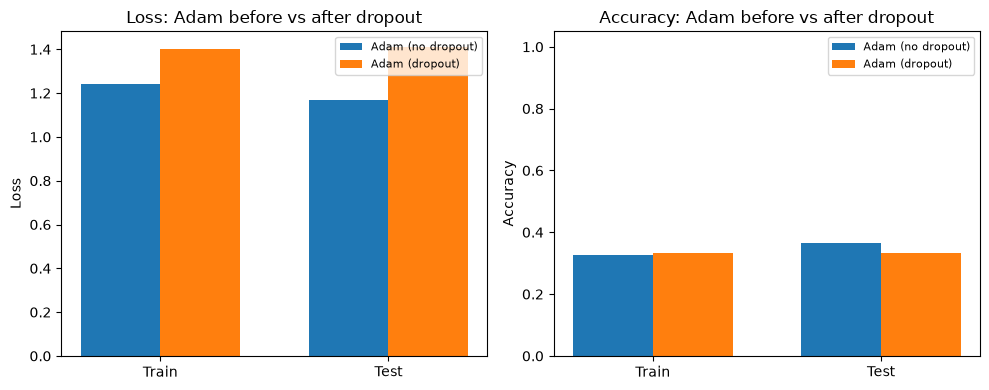

In [45]:
# Compare Adam model before and after dropout: losses and accuracies

model_adam.eval()
model_adam_dropout.eval()

with torch.no_grad():
    train_loss_adam = loss(model_adam(X_train_tensor), Y_train_tensor).item()
    test_loss_adam = loss(model_adam(X_test_tensor), Y_test_tensor).item()
    train_loss_adam_do = loss(model_adam_dropout(X_train_tensor), Y_train_tensor).item()
    test_loss_adam_do = loss(model_adam_dropout(X_test_tensor), Y_test_tensor).item()

    _, pred_adam_train = torch.max(model_adam(X_train_tensor), 1)
    _, pred_adam_test = torch.max(model_adam(X_test_tensor), 1)
    _, pred_adam_do_train = torch.max(model_adam_dropout(X_train_tensor), 1)
    _, pred_adam_do_test = torch.max(model_adam_dropout(X_test_tensor), 1)

    acc_adam_train = (pred_adam_train == Y_train_tensor).sum().item() / Y_train_tensor.size(0)
    acc_adam_test = (pred_adam_test == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
    acc_adam_do_train = (pred_adam_do_train == Y_train_tensor).sum().item() / Y_train_tensor.size(0)
    acc_adam_do_test = (pred_adam_do_test == Y_test_tensor).sum().item() / Y_test_tensor.size(0)

print(f'Adam (no dropout)  -> Train loss: {train_loss_adam:.4f}, Test loss: {test_loss_adam:.4f}, Train acc: {acc_adam_train:.4f}, Test acc: {acc_adam_test:.4f}')
print(f'Adam (dropout)     -> Train loss: {train_loss_adam_do:.4f}, Test loss: {test_loss_adam_do:.4f}, Train acc: {acc_adam_do_train:.4f}, Test acc: {acc_adam_do_test:.4f}')

# Simple side-by-side bar plots for visual comparison
labels = ['Train', 'Test']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(x - width/2, [train_loss_adam, test_loss_adam], width, label='Adam (no dropout)')
plt.bar(x + width/2, [train_loss_adam_do, test_loss_adam_do], width, label='Adam (dropout)')
plt.xticks(x, labels)
plt.ylabel('Loss')
plt.title('Loss: Adam before vs after dropout')
plt.legend(fontsize=8)

plt.subplot(1,2,2)
plt.bar(x - width/2, [acc_adam_train, acc_adam_test], width, label='Adam (no dropout)')
plt.bar(x + width/2, [acc_adam_do_train, acc_adam_do_test], width, label='Adam (dropout)')
plt.xticks(x, labels)
plt.ylim(0,1.05)
plt.ylabel('Accuracy')
plt.title('Accuracy: Adam before vs after dropout')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()